In [ ]:
import kagglehub
import os # Import os module

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 896M/896M [00:08<00:00, 104MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions/7
Contents of base_path (/root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions):
['7']
Contents of path (/root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions/7):
['file_renamer.py', 'train', 'folder_renamer.py', 'test']


In [ ]:
import os

# Check for GPU availability
import tensorflow as tf

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPU found:", physical_devices)
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No GPU found. Using CPU.")

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Load and Preprocess the Dataset

We'll use `tf.keras.utils.image_dataset_from_directory` to load the images, splitting them into training and validation sets. We'll also define some basic preprocessing parameters like image size and batch size.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define dataset parameters
img_height = 64
img_width = 64
batch_size = 32

# Assuming `path` from the previous cell is the directory where the dataset is downloaded
data_dir = path # Use the path variable from kagglehub.dataset_download

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2922 files belonging to 2 classes.
Using 2338 files for training.
Found 2922 files belonging to 2 classes.
Using 584 files for validation.
Found 2 classes: ['test', 'train']


### Build and Train ResNet Model

We will use a pre-trained ResNet50 model as a base and add a custom classification head for our specific task. This approach, known as transfer learning, is effective for image classification with limited data.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization

# Create the base model from the pre-trained ResNet50, without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top
model = Sequential([
    keras.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255), # Normalize pixel values to [0, 1]
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,686,658 (97.99 MB)

 Trainable params: 2,098,434 (8.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [ ]:
epochs = 10 # You can increase this for better performance

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 234ms/step - accuracy: 0.7489 - loss: 0.5950 - val_accuracy: 0.9110 - val_loss: 0.4626
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9016 - loss: 0.3243 - val_accuracy: 0.9127 - val_loss: 0.3137
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9102 - loss: 0.3078 - val_accuracy: 0.8664 - val_loss: 0.4403
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9085 - loss: 0.3044 - val_accuracy: 0.9075 - val_loss: 0.3353
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9106 - loss: 0.2823 - val_accuracy: 0.9110 - val_loss: 0.3336
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9136 - loss: 0.2859 - val_accuracy: 0.9007 - val_loss: 0.3359
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9098 - loss: 0.2832 - val_accuracy: 0.8767 - val_loss: 0.4046
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9106 - loss: 0.2788 - val_accuracy: 0.9127 -

### Summarize Training Results

After training, we will evaluate the model on the validation set to get its final performance metrics.

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9075 - loss: 0.3032
Validation Loss: 0.3032
Validation Accuracy: 0.9075


### Display Training Plots

These plots will show the training and validation accuracy and loss over the epochs, helping us understand the model's learning process and identify potential overfitting.

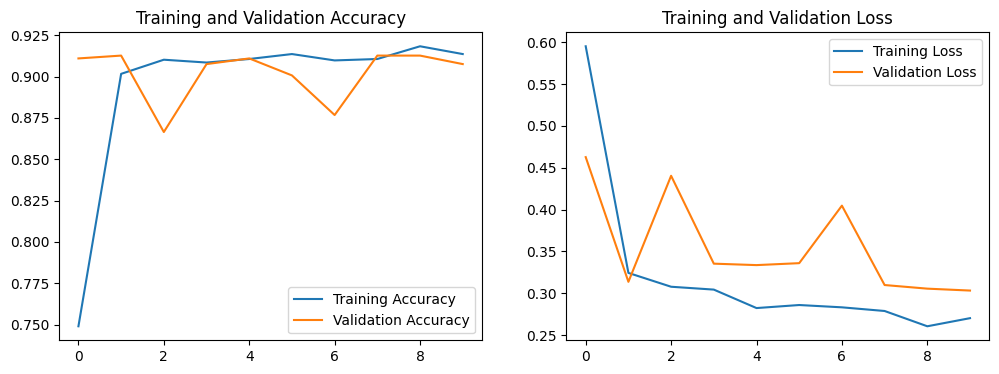

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()